# Loading the dataset

In [2]:
from keras.datasets import mnist
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np


(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [60]:
print("train_images shape" ,train_images[0].shape)
print("test_images shape" ,test_images[0].shape)

train_images shape (28, 28)
test_images shape (28, 28)


In [61]:
print("size of train",len(train_images))
print("size of test",len(test_images))

size of train 60000
size of test 10000


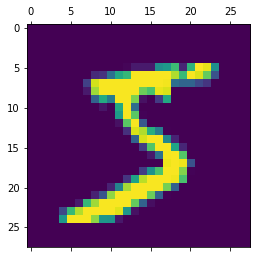

In [62]:
plt.matshow(train_images[0])

In [63]:
train_labels[0]

5

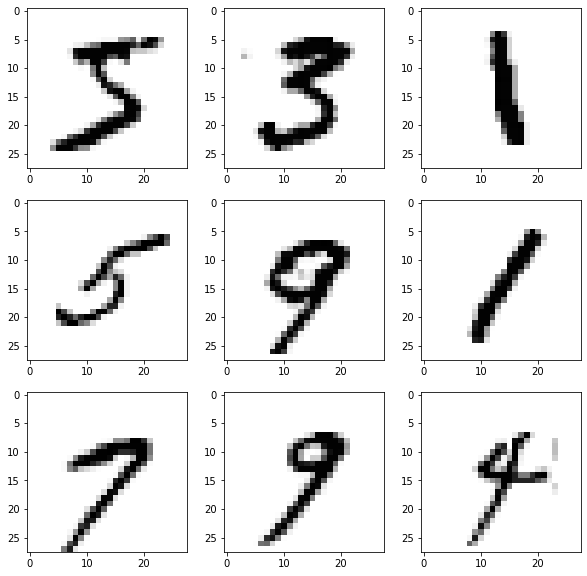

In [64]:
from sklearn.utils import shuffle
import cv2

shuff = shuffle(train_images[:100])
fig, ax = plt.subplots(3,3, figsize = (10,10))
axes = ax.flatten()
for i in range(9):
    _, shu = cv2.threshold(shuff[i], 30, 200, cv2.THRESH_BINARY)
    axes[i].imshow(np.reshape(shuff[i], (28,28)), cmap="Greys")
plt.show()

# Reshaping the data

In [65]:
# train_images = train_images/255
# test_images = test_images/255


train_images = tf.keras.utils.normalize(train_images,axis=1)
test_images = tf.keras.utils.normalize(test_images,axis=1)

In [66]:
# We can flatten images
# Or we can use model.add(layers.Flatten())

# train_images_flattend = train_images.reshape(len(train_images),28*28)
# test_images_flattend = test_images.reshape(len(test_images),28*28)

# test_images.shape
# model = keras.Sequential([
#     keras.layers.Dense(10, input_shape=(784,), activation='sigmoid')
# ])

# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])

# model.fit(train_images_flattend, train_labels, epochs=5)

# Model

In [67]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=5)

# model = keras.Sequential([
#         keras.layers.Dense(10, input_shape=(784,), activation='sigmoid')
#     ])

# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])

# model.fit(X_train_flattened, y_train, epochs=5)

model.save('mnist.h5')

Epoch 1/5
1875/1875 [==============================] - 5s 2ms/step - loss: 0.2643 - accuracy: 0.9240
Epoch 2/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1085 - accuracy: 0.9664
Epoch 3/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0753 - accuracy: 0.9761
Epoch 4/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0547 - accuracy: 0.9828
Epoch 5/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0420 - accuracy: 0.9865


# Evaluation

In [68]:
val_loss, val_acc = model.evaluate(test_images,test_labels)

print("val_loss = ",val_loss, "val_acc = " ,val_acc)

313/313 [==============================] - 1s 1ms/step - loss: 0.0989 - accuracy: 0.9717
val_loss =  0.09887522459030151 val_acc =  0.9717000126838684


# Prediction

In [69]:
predictions = model.predict(test_images)

In [70]:
predictions[0]

array([1.4403462e-04, 1.7996532e-01, 6.5609562e-01, 5.6770116e-01,
       6.8651589e-06, 1.1343360e-03, 8.4733776e-10, 9.9999976e-01,
       1.4076233e-03, 2.7472079e-03], dtype=float32)

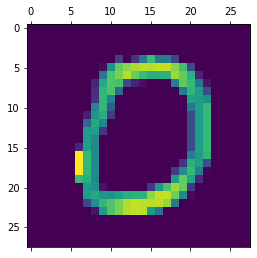

In [71]:
plt.matshow(test_images[10])

In [72]:
print(np.argmax(predictions[10]))

0


# Testing

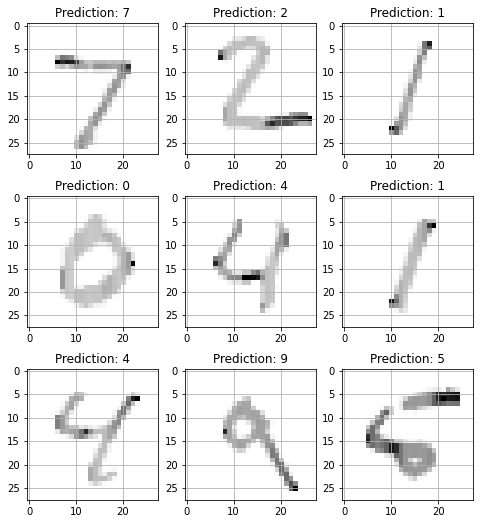

In [73]:
word_dict = {0:"0",1:"1",2:"2",3:"3",4:"4",5:"5",6:"6",7:"7",8:"8",9:"9"}


fig, axes = plt.subplots(3,3, figsize=(8,9))
axes = axes.flatten()
for i,ax in enumerate(axes):
    img = np.reshape(test_images[i], (28,28))
    ax.imshow(img, cmap="Greys")
    
    
    pred = word_dict[np.argmax(predictions[i])]
    ax.set_title("Prediction: "+pred)
    ax.grid()
    

(208, 175, 3)
(208, 175)
resize  (28, 28)
(1, 28, 28, 1)
2


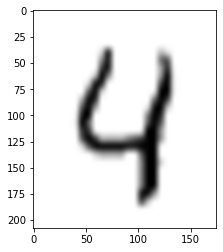

In [5]:
import cv2
from keras.models import load_model
IMG_SIZE = 28

model = load_model('mnist.h5')

img = cv2.imread("4.png")

print(img.shape)

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
print(gray.shape)

resize = cv2.resize(gray,(28,28),interpolation=cv2.INTER_AREA)
print("resize ",resize.shape)

# newimg = tf.keras.utils.normalize(resize,axis=1) 
newimg = resize/250.0

newimg = np.array(newimg).reshape(-1,IMG_SIZE,IMG_SIZE,1)
print(newimg.shape)

prediction = model.predict(newimg)
print(np.argmax(prediction))

plt.imshow(img)





In [9]:
#import required library
from keras.models  import load_model
import numpy as np
import cv2

#load your model
model = load_model('mnist.h5')

#load your image to recognit image
image = cv2.imread("1.jpg")
image1 = cv2.imread("1.jpg")

#perform some basic operation to smooth image
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image = cv2.GaussianBlur(image, (5, 5), 0)

#find threshold image
ret, image = cv2.threshold(image, 90, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

#find contours on image and draw it.
ctrs, hier = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
rects = [cv2.boundingRect(ctr) for ctr in ctrs]
for rect in rects:
    #draw rectangle on image using contours
    cv2.rectangle(image1, (rect[0], rect[1]), (rect[0] + rect[2], rect[1] + rect[3]), (0, 255, 0), 3)
    leng = int(rect[3] * 1.6)
    pt1 = abs(int(rect[1] + rect[3] // 2 - leng // 2))
    pt2 = abs(int(rect[0] + rect[2] // 2 - leng // 2))
    #resize image
    roi = image[pt1:pt1+leng, pt2:pt2+leng]
    roi = cv2.resize(roi,(28, 28), interpolation=cv2.INTER_AREA)

    #reshape your image according to your model
    roi = roi.reshape(-1,28, 28, 1)
    roi = np.array(roi, dtype='float32')
    roi /= 255
    #to perform prediction on your image
    pred_array = model.predict(roi)
    pred_array = np.argmax(pred_array)

    #print result
    print('Result: {0}'.format(pred_array))

    #print text on your image
    cv2.putText(image1, str(pred_array), (rect[0], rect[1]),cv2.FONT_HERSHEY_DUPLEX, 2, (0, 0, 255), 3)
    #show your image
cv2.imshow("Result4",image1)

#save your image
cv2.imwrite("image4.jpg",image1)

cv2.waitKey(0)

Result: 8
Result: 2
Result: 3
Result: 7
Result: 7
Result: 3
Result: 2
Result: 1
Result: 2
Result: 2


-1